In [28]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
%matplotlib inline

In [29]:
words = open('names.txt', 'r').read().splitlines()
words

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella',
 'avery',
 'sofia',
 'camila',
 'aria',
 'scarlett',
 'victoria',
 'madison',
 'luna',
 'grace',
 'chloe',
 'penelope',
 'layla',
 'riley',
 'zoey',
 'nora',
 'lily',
 'eleanor',
 'hannah',
 'lillian',
 'addison',
 'aubrey',
 'ellie',
 'stella',
 'natalie',
 'zoe',
 'leah',
 'hazel',
 'violet',
 'aurora',
 'savannah',
 'audrey',
 'brooklyn',
 'bella',
 'claire',
 'skylar',
 'lucy',
 'paisley',
 'everly',
 'anna',
 'caroline',
 'nova',
 'genesis',
 'emilia',
 'kennedy',
 'samantha',
 'maya',
 'willow',
 'kinsley',
 'naomi',
 'aaliyah',
 'elena',
 'sarah',
 'ariana',
 'allison',
 'gabriella',
 'alice',
 'madelyn',
 'cora',
 'ruby',
 'eva',
 'serenity',
 'autumn',
 'adeline',
 'hailey',
 'gianna',
 'valentina',
 'isla',
 'eliana',
 'quinn',
 'nevaeh',
 'ivy',
 'sadie',
 'piper',
 'lydia',
 'alexa',
 'josephine',
 'emery',
 'julia'

In [30]:
chars = sorted(list(set(''.join(words))))
stoi = {j:i + 1 for i,j in enumerate(chars)}
stoi['.'] = 0
itos = {j:i for i,j in stoi.items()}

In [50]:
import random
block_size = 3

def build_data(words):
    
    x = []
    y = []

    for word in words:
        context = [0] * block_size

        for ch in word + '.':
            x.append(context)
            y.append(stoi[ch])
            context = context[1:] + [stoi[ch]]

    x = torch.tensor(x)
    y = torch.tensor(y)

    print(x.shape, y.shape)
    return x,y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

x_train, y_train = build_data(words[:n1])
x_val, y_val = build_data(words[n1:n2])
x_test, y_test = build_data(words[n2:])

torch.Size([182437, 3]) torch.Size([182437])
torch.Size([22781, 3]) torch.Size([22781])
torch.Size([22928, 3]) torch.Size([22928])


In [51]:
# a = torch.tensor([[[1],[2],[3]],[[4],[5],[6]]])
# a = torch.cat((a[0, :, :], a[1, :, :]), 0)
# print(a)
# a.shape

In [118]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,15), generator = g)
w1 = torch.randn((45, 200), generator = g)
b1 = torch.randn(200, generator = g)
w2 = torch.randn((200, 27), generator = g)
b2 = torch.randn(27, generator = g)
parameters = [C, w1, b1, w2, b2]

In [119]:
sum(p.nelement() for p in parameters)

15032

In [120]:
for p in parameters:
    p.requires_grad = True

In [132]:
for i in range(20000):
    # forward pass
    ix = torch.randint(0, x_train.shape[0], (100,))

    emb = C[x_train[ix]]
    h = torch.tanh((emb.view(-1, 45)) @ w1 + b1)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, y_train[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.001
    for p in parameters:
        p.data -= lr * p.grad

print(loss.item())

2.1578567028045654


In [133]:
emb = C[x_train]
h = torch.tanh((emb.view(-1, 45)) @ w1 + b1)
logits = h @ w2 + b2
l = F.cross_entropy(logits, y_train)
print(l.item())

2.1157710552215576


In [134]:
emb = C[x_val]
h = torch.tanh((emb.view(-1, 45)) @ w1 + b1)
logits = h @ w2 + b2
l = F.cross_entropy(logits, y_val)
print(l.item())

2.177109718322754


In [138]:
g = torch.Generator().manual_seed(2147483647 + 5)

for i in range(30):

    ix = 0
    name = []
    context = [0] * block_size

    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ w1 + b1)
        logits = h @ w2 + b2
        p = F.softmax(logits, dim=1)

        ix = torch.multinomial(p, num_samples=1, replacement=True,generator=g).item()
        context = context[1:] + [ix]
        if ix == 0:
            break
        name.append(itos[ix])

    print(''.join(name))


treigh
day
gavrie
deylah
lin
greyah
sorvyn
jamoylliet
zita
mea
jakyavio
ito
abdu
aharlena
ziah
tar
yura
mice
judn
alii
mukie
sof
noah
millia
marvie
tyrenella
miha
lar
siah
yountie


In [433]:
g = torch.Generator().manual_seed(2147483647)

for i in range(30):

    ix = 0
    name = []
    context = [0] * block_size

    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ w1 + b1)
        logits = h @ w2 + b2
        p = F.softmax(logits, dim=1)

        ix = torch.multinomial(p, num_samples=1, replacement=True,generator=g).item()
        context = context[1:] + [ix]
        if ix == 0:
            break
        name.append(itos[ix])

    print(''.join(name))


min
ayvanie
wistyn
sanna
oghlee
apimsery
rim
oigh
lamamanth
hankonbylen
elyn
ram
bradaliya
ion
chrissa
mell
bebd
amillia
axous
lellionna
zaiverjeice
kryseston
derillarion
deukanse
kisushir
sten
abuel
kili
halina
manee


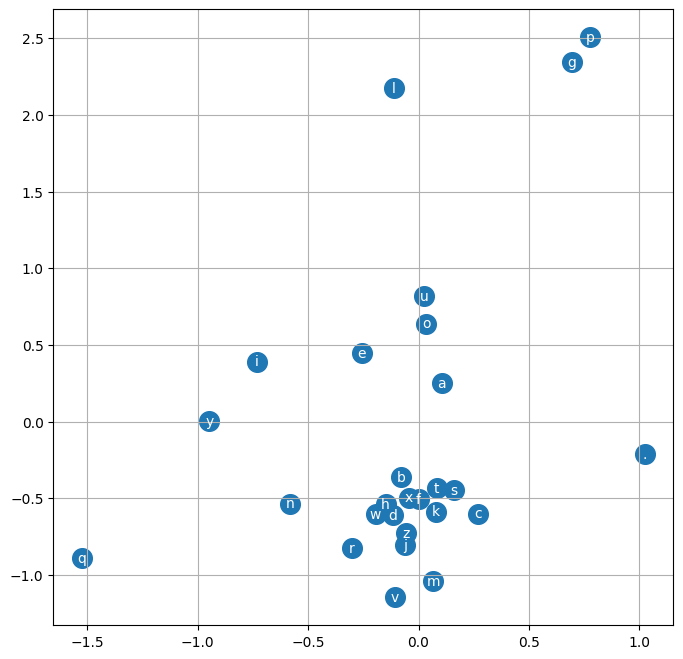

In [281]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')